<a href="https://colab.research.google.com/github/jamesalphonso36-la/CSL701-CE08_Machine-Learning-Lab/blob/main/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


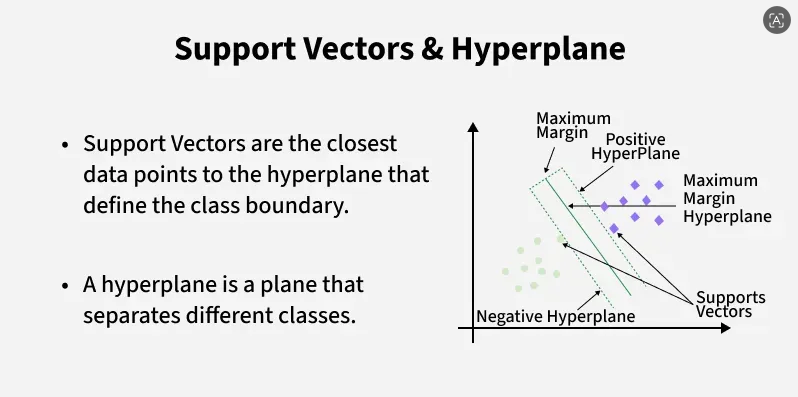
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Load Iris dataset from scikit-learn
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['Species'] = iris.target
df['Species_Name'] = df['Species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Dataset loaded successfully!")

Dataset loaded successfully!


# Task 2: Explore the Dataset

In [2]:
# Display first few rows
print("First 5 rows:")
print(df.head())

# Dataset summary
print("\nDataset Info:")
df.info()

# Class distribution
print("\nClass Counts:")
print(df['Species_Name'].value_counts())

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species Species_Name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    floa

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [3]:
# Define features (X) and target (y)
X = df.drop(columns=['Species', 'Species_Name'])
y = df['Species']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled.")

Data successfully split and scaled.


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [5]:
from sklearn.svm import SVC

# Initialize Linear SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Performance Metrics
svm_acc = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {svm_acc:.4f}\n")

print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=iris.target_names))

SVM Accuracy: 1.0000

SVM Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

SVM Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

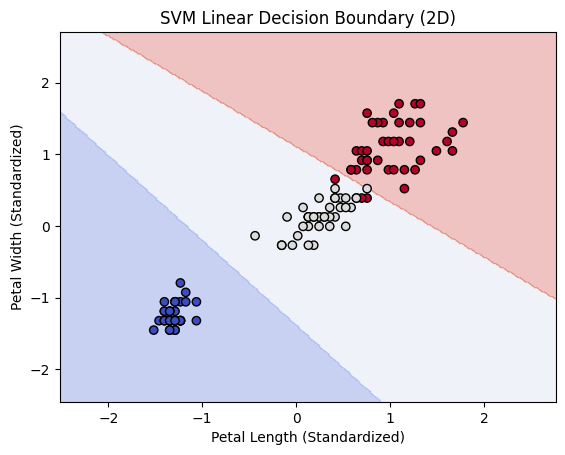

In [7]:
# Select 2 features: Petal Length (index 2) and Petal Width (index 3)
X_2d = X.iloc[:, [2, 3]].values
y_2d = y.values

# Train/test split and scaling for 2D
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d)

scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Train SVM on 2D data
svm_2d = SVC(kernel='linear', random_state=42)
svm_2d.fit(X_train_2d_scaled, y_train_2d)

# Helper function to plot mesh decision surface
def plot_decision_boundary(clf, X_data, y_data, title):
    x_min, x_max = X_data[:, 0].min() - 1, X_data[:, 0].max() + 1
    y_min, y_max = X_data[:, 1].min() - 1, X_data[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    scatter = plt.scatter(X_data[:, 0], X_data[:, 1], c=y_data, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.xlabel('Petal Length (Standardized)')
    plt.ylabel('Petal Width (Standardized)')
    plt.title(title)
    plt.show()

# Plot SVM boundary
plot_decision_boundary(svm_2d, X_train_2d_scaled, y_train_2d, "SVM Linear Decision Boundary (2D)")

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

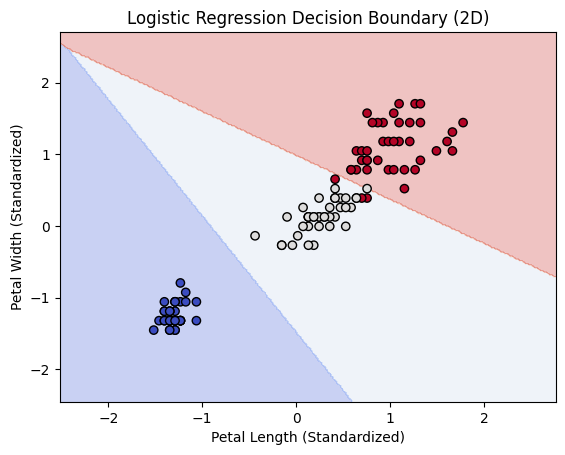

In [8]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression on 2D data
log_reg_2d = LogisticRegression(random_state=42)
log_reg_2d.fit(X_train_2d_scaled, y_train_2d)

# Plot Logistic Regression boundary
plot_decision_boundary(log_reg_2d, X_train_2d_scaled, y_train_2d, "Logistic Regression Decision Boundary (2D)")

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

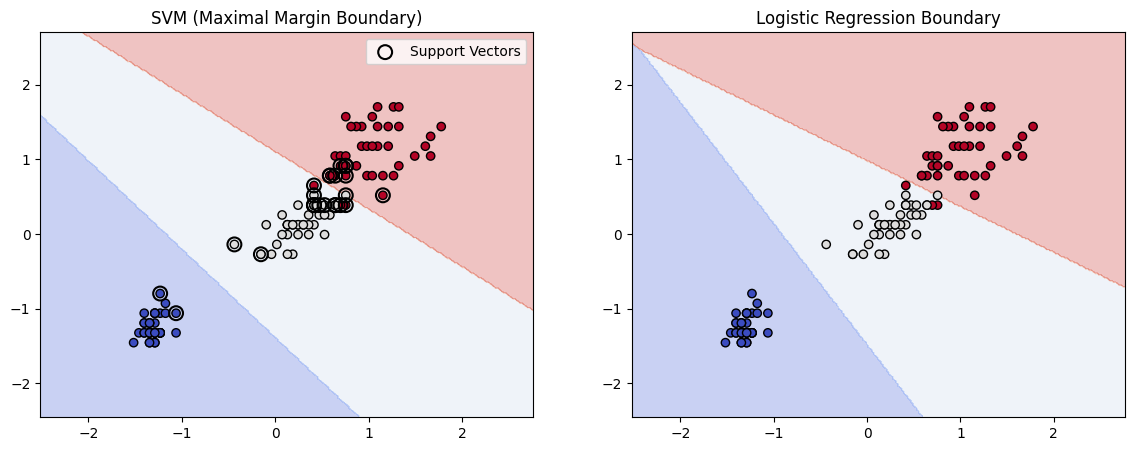

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_min, x_max = X_train_2d_scaled[:, 0].min() - 1, X_train_2d_scaled[:, 0].max() + 1
y_min, y_max = X_train_2d_scaled[:, 1].min() - 1, X_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# SVM Subplot
Z1 = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[0].contourf(xx, yy, Z1, alpha=0.3, cmap=plt.cm.coolwarm)
axes[0].scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1], c=y_train_2d, cmap=plt.cm.coolwarm, edgecolors='k')
axes[0].scatter(svm_2d.support_vectors_[:, 0], svm_2d.support_vectors_[:, 1], s=100, facecolors='none', edgecolors='k', linewidths=1.5, label='Support Vectors')
axes[0].set_title("SVM (Maximal Margin Boundary)")
axes[0].legend()

# Logistic Regression Subplot
Z2 = log_reg_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z2, alpha=0.3, cmap=plt.cm.coolwarm)
axes[1].scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1], c=y_train_2d, cmap=plt.cm.coolwarm, edgecolors='k')
axes[1].set_title("Logistic Regression Boundary")

plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [10]:
y_pred_svm_2d = svm_2d.predict(X_test_2d_scaled)
y_pred_lr_2d = log_reg_2d.predict(X_test_2d_scaled)

print("=== SVM (2D Features) Performance ===")
print("Accuracy:", accuracy_score(y_test_2d, y_pred_svm_2d))
print(classification_report(y_test_2d, y_pred_svm_2d, target_names=iris.target_names))

print("\n=== Logistic Regression (2D Features) Performance ===")
print("Accuracy:", accuracy_score(y_test_2d, y_pred_lr_2d))
print(classification_report(y_test_2d, y_pred_lr_2d, target_names=iris.target_names))

=== SVM (2D Features) Performance ===
Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


=== Logistic Regression (2D Features) Performance ===
Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.